# Gaussian Scale Space

## Introduction

In this homework, we'll explore Gaussian Scale Space (GSS), a fundamental concept in computer vision that helps us analyze images at multiple scales. GSS is crucial for scale-invariant feature detection and forms the basis for many modern computer vision algorithms like SIFT.

## Prerequisites
First, let's import our required libraries:

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from typing import List, Tuple
from scipy.ndimage import gaussian_filter

In [14]:
img = cv2.imread("image1.jpeg", cv2.IMREAD_GRAYSCALE)

## Part 1: Building the Scale Space

### 1.1 Basic Gaussian Blur Function
Let's start with the fundamental operation in scale space construction:


In [15]:
def gaussian_blur(img: np.ndarray, sigma: float) -> np.ndarray:
    """
    Apply Gaussian blur to an image with specified sigma.

    Args:
        img: Input image (grayscale or color)
        sigma: Standard deviation of the Gaussian kernel

    Returns:
        np.ndarray: Blurred image
    """

    # If grayscale image
    if img.ndim == 2:
        return gaussian_filter(img, sigma=sigma)

    # If color image, apply blur channel-wise
    elif img.ndim == 3:
        blurred = np.zeros_like(img, dtype=np.float32)
        for c in range(img.shape[2]):
            blurred[..., c] = gaussian_filter(img[..., c], sigma=sigma)
        return blurred.astype(img.dtype)

    else:
        raise ValueError("Unsupported image format. Expected 2D or 3D array.")

    return gaussian_filter(img, sigma=sigma)

array([[202, 201, 202, ...,  28,  20,  16],
       [196, 196, 197, ...,  30,  22,  18],
       [183, 184, 186, ...,  34,  26,  21],
       ...,
       [133, 135, 141, ...,  51,  44,  44],
       [154, 156, 161, ...,  49,  43,  43],
       [170, 172, 175, ...,  49,  44,  44]], dtype=uint8)
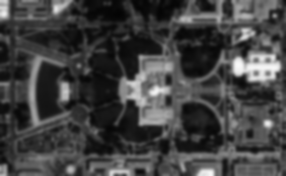

In [24]:
sigma = 1.6

gaussian_filter(img, sigma)

### 1.2 Scale Space Generation
Now let's implement the complete scale space:

In [25]:
def create_scale_space(img: np.ndarray, num_octaves: int, scales_per_octave: int,
                      initial_sigma: float = 1.6) -> List[List[np.ndarray]]:
    """
    Create a Gaussian scale space representation of an image.

    Args:
        img: Input image
        num_octaves: Number of octaves to compute
        scales_per_octave: Number of scales per octave
        initial_sigma: Initial sigma value

    Returns:
        List[List[np.ndarray]]: Scale space as list of octaves, each containing list of scales
    """
    k = 2 ** (1.0 / scales_per_octave)  # Scale multiplication factor
    scale_space = []

    # Create first octave
    current_img = img.copy()
    current_octave = []
    sigma = initial_sigma

    for octave in range(num_octaves):
        current_octave = []
        for scale in range(scales_per_octave + 3):  # +3 for keypoint detection
            blurred = gaussian_blur(current_img, sigma)
            current_octave.append(blurred)
            sigma *= k

        scale_space.append(current_octave)

        # Prepare next octave
        if octave < num_octaves - 1:
            current_img = cv2.resize(current_octave[0],
                                   (current_img.shape[1] // 2, current_img.shape[0] // 2))
            sigma = initial_sigma

    return scale_space

In [26]:
num_octaves = 4
scales_per_octave = 3
initial_sigma = 1.6

create_scale_space(img, num_octaves, scales_per_octave, initial_sigma)

[[array([[202, 201, 202, ...,  28,  20,  16],
         [196, 196, 197, ...,  30,  22,  18],
         [183, 184, 186, ...,  34,  26,  21],
         ...,
         [133, 135, 141, ...,  51,  44,  44],
         [154, 156, 161, ...,  49,  43,  43],
         [170, 172, 175, ...,  49,  44,  44]], dtype=uint8),
  array([[197, 198, 199, ...,  32,  24,  20],
         [192, 193, 194, ...,  33,  26,  22],
         [183, 184, 186, ...,  36,  29,  25],
         ...,
         [140, 142, 146, ...,  58,  50,  47],
         [153, 154, 158, ...,  56,  48,  45],
         [162, 163, 166, ...,  55,  47,  44]], dtype=uint8),
  array([[193, 193, 194, ...,  36,  30,  27],
         [190, 190, 191, ...,  37,  31,  28],
         [185, 186, 186, ...,  40,  33,  30],
         ...,
         [145, 146, 147, ...,  62,  56,  53],
         [151, 152, 153, ...,  61,  55,  51],
         [155, 156, 156, ...,  61,  54,  50]], dtype=uint8),
  array([[189, 189, 188, ...,  42,  37,  35],
         [188, 188, 187, ...,  43,  38,

## Part 2: Exercises

### Exercise 1: Scale Space Implementation
Complete the following functions:

In [27]:
def load_and_preprocess_image(path: str) -> np.ndarray:
    """
    TODO: Implement a function that:
    1. Loads an image and converts to grayscale
    2. Normalizes pixel values to [0,1]
    3. Optionally applies initial smoothing
    4. Returns the preprocessed image
    """

    """
    Load an image, convert to grayscale, normalize, and optionally smooth.
    """
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = img.astype(np.float32) / 255.0  # normalize to [0,1]
    # Optional initial smoothing
    img = gaussian_filter(img, sigma=0.5)
    return img

    pass

In [28]:
load_and_preprocess_image("image1.jpeg")

array([[0.7659527 , 0.73330146, 0.74131227, ..., 0.0189053 , 0.06349728,
        0.06694794],
       [0.9302926 , 0.9165612 , 0.926104  , ..., 0.05731244, 0.0930588 ,
        0.02071191],
       [0.7407492 , 0.7282332 , 0.7156248 , ..., 0.10968194, 0.17215523,
        0.03692284],
       ...,
       [0.39796132, 0.38138917, 0.40636352, ..., 0.05379058, 0.07582515,
        0.24476911],
       [0.72697693, 0.6847082 , 0.6783414 , ..., 0.04877569, 0.04349234,
        0.14597553],
       [0.7417823 , 0.79540205, 0.8140424 , ..., 0.14827229, 0.19416381,
        0.27893752]], dtype=float32)

In [29]:
def visualize_scale_space(scale_space: List[List[np.ndarray]]) -> None:
    """
    TODO: Create a visualization function that:
    1. Arranges all scales and octaves in a grid
    2. Labels each image with its octave and scale
    3. Shows how detail is progressively removed
    4. Optionally adds a visualization of the Gaussian kernels used
    """

    """
    Visualize the Gaussian scale space.
    """
    num_octaves = len(scale_space)
    num_scales = len(scale_space[0])
    fig, axes = plt.subplots(num_octaves, num_scales, figsize=(15, 8))

    for o in range(num_octaves):
        for s in range(num_scales):
            axes[o, s].imshow(scale_space[o][s], cmap='gray')
            axes[o, s].axis('off')
            axes[o, s].set_title(f"Octave {o}, Scale {s}")
    plt.tight_layout()
    plt.show()
    pass

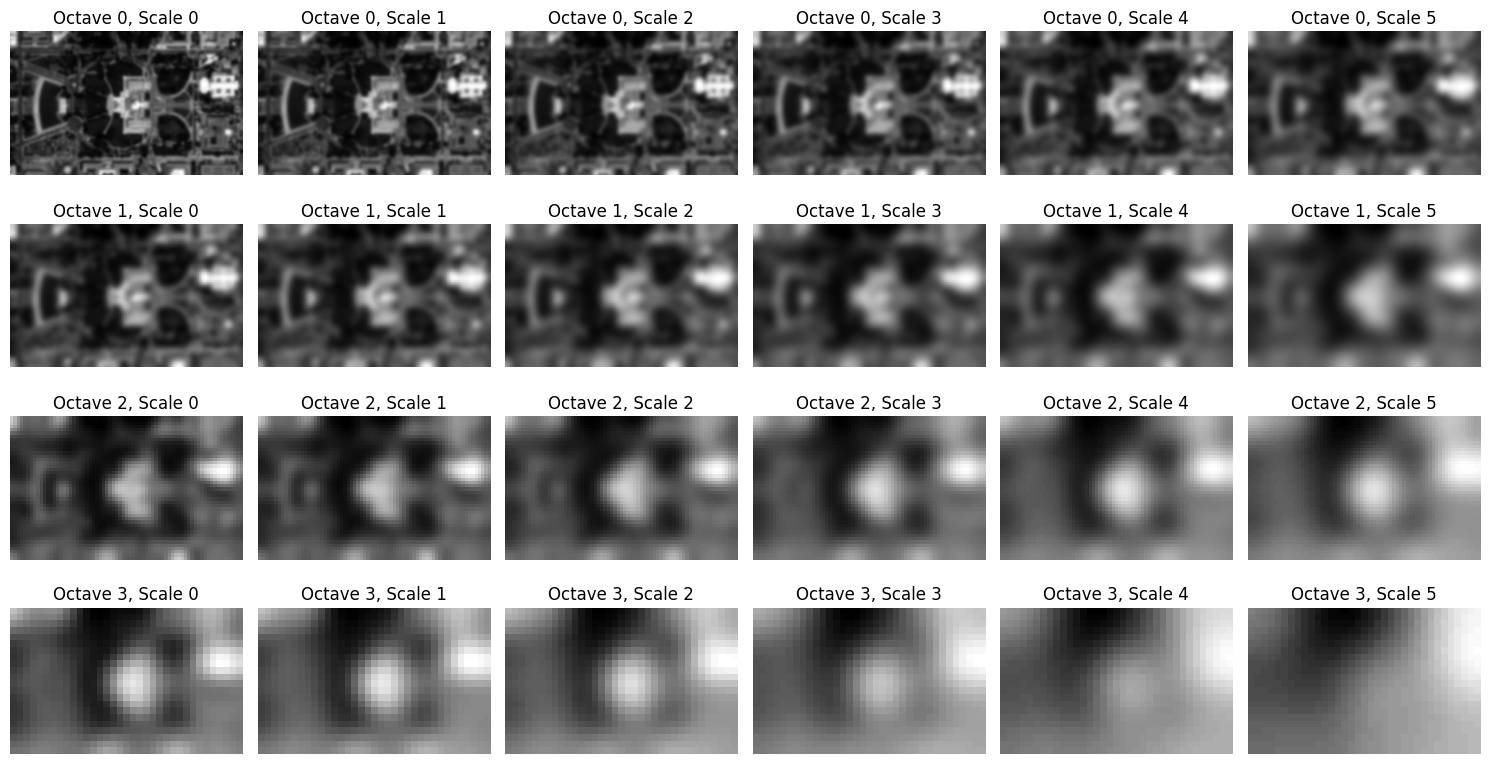

In [30]:
visualize_scale_space(create_scale_space(img, num_octaves, scales_per_octave, initial_sigma))

### Exercise 2: Scale Space Analysis

In [31]:
def analyze_scale_space(scale_space: List[List[np.ndarray]]) -> dict:
    """
    TODO: Write a function that computes:
    1. The effective sigma at each scale
    2. The amount of detail preserved at each scale (using image gradients)
    3. The memory requirements of the scale space
    4. The relationship between octaves and spatial resolution
    """

    """
    Analyze properties of the scale space.
    """
    analysis = {
        "effective_sigma": [],
        "detail_preserved": [],
        "memory_usage": 0,
        "octave_resolution": []
    }

    for o, octave in enumerate(scale_space):
        for s, img in enumerate(octave):
            # Approximate sigma for this scale
            sigma = 1.6 * (2 ** (o + s/len(octave)))
            analysis["effective_sigma"].append((o, s, sigma))

            # Detail preserved: mean gradient magnitude
            gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
            gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
            grad_mag = np.sqrt(gx**2 + gy**2)
            analysis["detail_preserved"].append((o, s, np.mean(grad_mag)))

            # Memory usage
            analysis["memory_usage"] += img.nbytes

        # Resolution per octave
        analysis["octave_resolution"].append((o, octave[0].shape))

    return analysis
    pass

In [32]:
analyze_scale_space(create_scale_space(img, num_octaves, scales_per_octave, initial_sigma))

{'effective_sigma': [(0, 0, 1.6),
  (0, 1, 1.795939277294997),
  (0, 2, 2.015873679831797),
  (0, 3, 2.2627416997969525),
  (0, 4, 2.539841683149119),
  (0, 5, 2.850875898049086),
  (1, 0, 3.2),
  (1, 1, 3.591878554589994),
  (1, 2, 4.031747359663594),
  (1, 3, 4.525483399593905),
  (1, 4, 5.079683366298238),
  (1, 5, 5.701751796098172),
  (2, 0, 6.4),
  (2, 1, 7.183757109179986),
  (2, 2, 8.063494719327188),
  (2, 3, 9.05096679918781),
  (2, 4, 10.159366732596476),
  (2, 5, 11.403503592196344),
  (3, 0, 12.8),
  (3, 1, 14.367514218359972),
  (3, 2, 16.126989438654377),
  (3, 3, 18.10193359837562),
  (3, 4, 20.318733465192953),
  (3, 5, 22.80700718439269)],
 'detail_preserved': [(0, 0, np.float32(66.85363)),
  (0, 1, np.float32(54.874176)),
  (0, 2, np.float32(44.71679)),
  (0, 3, np.float32(36.221382)),
  (0, 4, np.float32(29.21133)),
  (0, 5, np.float32(23.403572)),
  (1, 0, np.float32(62.173073)),
  (1, 1, np.float32(52.59529)),
  (1, 2, np.float32(43.550224)),
  (1, 3, np.float32(3

### Exercise 3: Feature Detection

In [33]:
def detect_blob_features(scale_space: List[List[np.ndarray]]) -> List[Tuple[int, int, float]]:
    """
    TODO: Implement a basic blob detector that:
    1. Finds local maxima in scale space (x, y, σ)
    2. Computes feature response strength
    3. Applies non-maximum suppression
    4. Returns list of features with their scales
    """

    """
    Detect blob-like features using scale-space extrema.
    """
    features = []
    for o, octave in enumerate(scale_space):
        for s, img in enumerate(octave):
            # Laplacian of Gaussian response
            log = cv2.Laplacian(img, cv2.CV_32F)
            # Find local maxima
            coords = np.argwhere(log > np.percentile(log, 99))  # top 1% responses
            for (y, x) in coords:
                features.append((x, y, s))
    return features
    pass

In [34]:
detect_blob_features(create_scale_space(img, num_octaves, scales_per_octave, initial_sigma))

[(np.int64(62), np.int64(0), 0),
 (np.int64(75), np.int64(0), 0),
 (np.int64(76), np.int64(0), 0),
 (np.int64(77), np.int64(0), 0),
 (np.int64(237), np.int64(0), 0),
 (np.int64(238), np.int64(0), 0),
 (np.int64(223), np.int64(4), 0),
 (np.int64(223), np.int64(6), 0),
 (np.int64(25), np.int64(9), 0),
 (np.int64(37), np.int64(9), 0),
 (np.int64(50), np.int64(9), 0),
 (np.int64(51), np.int64(9), 0),
 (np.int64(0), np.int64(10), 0),
 (np.int64(213), np.int64(10), 0),
 (np.int64(242), np.int64(10), 0),
 (np.int64(0), np.int64(11), 0),
 (np.int64(223), np.int64(11), 0),
 (np.int64(224), np.int64(11), 0),
 (np.int64(240), np.int64(11), 0),
 (np.int64(241), np.int64(11), 0),
 (np.int64(242), np.int64(11), 0),
 (np.int64(243), np.int64(11), 0),
 (np.int64(244), np.int64(11), 0),
 (np.int64(246), np.int64(11), 0),
 (np.int64(247), np.int64(11), 0),
 (np.int64(248), np.int64(11), 0),
 (np.int64(252), np.int64(11), 0),
 (np.int64(270), np.int64(11), 0),
 (np.int64(271), np.int64(11), 0),
 (np.int6

### Exercise 4: Scale Space Properties

In [36]:
def demonstrate_scale_invariance(img: np.ndarray, scale_factor: float) -> None:
    """
    TODO: Create a function that:
    1. Resizes an input image by different scales
    2. Builds scale space for each version
    3. Detects features and shows they appear at corresponding scales
    4. Visualizes the scale invariance property
    """
    """
    Show scale invariance by resizing and comparing features.
    """
    # Resize image
    resized = cv2.resize(img, None, fx=scale_factor, fy=scale_factor)

    # Build scale spaces
    ss_original = create_scale_space(img, num_octaves=3, scales_per_octave=4)
    ss_resized = create_scale_space(resized, num_octaves=3, scales_per_octave=4)

    # Detect features
    feats_orig = detect_blob_features(ss_original)
    feats_resized = detect_blob_features(ss_resized)

    # Visualization
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original Features")
    plt.scatter([f[0] for f in feats_orig], [f[1] for f in feats_orig], c='r', s=10)

    plt.subplot(1,2,2)
    plt.imshow(resized, cmap='gray')
    plt.title("Resized Features")
    plt.scatter([f[0] for f in feats_resized], [f[1] for f in feats_resized], c='b', s=10)
    plt.show()
    pass

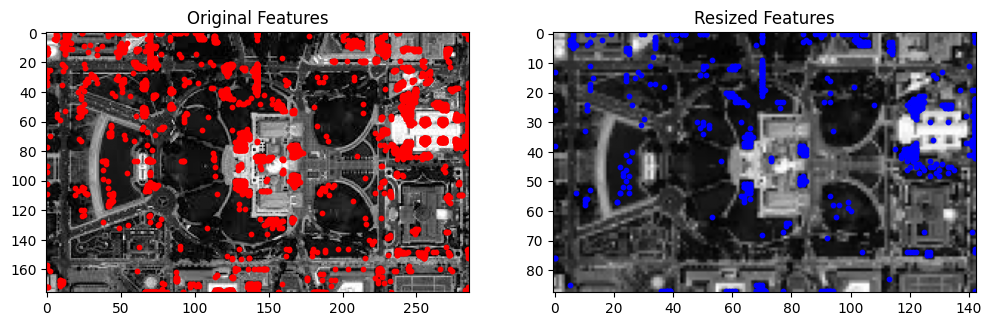

In [37]:
demonstrate_scale_invariance(img, 0.5)

## Part 4: Practical Applications

Implement one of the following applications for extra credits:

1. Basic SIFT-like feature detector using scale space extrema
2. Image enhancement using scale space decomposition
3. Multi-scale edge detection
4. Scale-adaptive blob detection


Good luck!


In [64]:
def multi_scale_edge_detection(img: np.ndarray, num_octaves: int = 3, scales_per_octave: int = 4, initial_sigma: float = 1.6):
    """
    Perform multi-scale edge detection using Gaussian scale space.

    Args:
        img: Input grayscale image (normalized to [0,1])
        num_octaves: Number of octaves
        scales_per_octave: Number of scales per octave
        initial_sigma: Initial sigma for Gaussian blur

    Returns:
        List of edge maps at different scales
    """
    # Build scale space
    scale_space = create_scale_space(img, num_octaves, scales_per_octave, initial_sigma)

    edge_maps = []
    for o, octave in enumerate(scale_space):
        for s, scale_img in enumerate(octave):
            # Compute gradients
            gx = cv2.Sobel(scale_img, cv2.CV_32F, 1, 0, ksize=3)
            gy = cv2.Sobel(scale_img, cv2.CV_32F, 0, 1, ksize=3)
            grad_mag = np.sqrt(gx**2 + gy**2)

            # Normalize for visualization
            grad_mag = grad_mag / grad_mag.max()
            edge_maps.append((o, s, grad_mag))
    return edge_maps


In [65]:
multi_scale_edge_detection(img)

[(0,
  0,
  array([[0.        , 0.00521676, 0.03651732, ..., 0.21388717, 0.12520225,
          0.        ],
         [0.18780337, 0.18045014, 0.17020555, ..., 0.21641697, 0.14119025,
          0.05738436],
         [0.2764883 , 0.27252266, 0.26707572, ..., 0.20951642, 0.14947633,
          0.07303464],
         ...,
         [0.3286559 , 0.33784315, 0.3464534 , ..., 0.23660178, 0.09229392,
          0.06260113],
         [0.38604027, 0.38471618, 0.35804233, ..., 0.22766244, 0.06281811,
          0.        ],
         [0.        , 0.06260113, 0.07825141, ..., 0.21910393, 0.05738436,
          0.        ]], dtype=float32)),
 (0,
  1,
  array([[0.        , 0.01844679, 0.03689358, ..., 0.22751038, 0.1475743 ,
          0.        ],
         [0.1906168 , 0.18610036, 0.17746879, ..., 0.2267613 , 0.1558605 ,
          0.06148929],
         [0.24595717, 0.24522589, 0.24012335, ..., 0.22174543, 0.15409173,
          0.07993608],
         ...,
         [0.2767018 , 0.28594175, 0.27938747, ..., 0